In [9]:
!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Baixando dados da Petrobras
df = yf.download('PETR4.SA', start='2018-01-01', end='2024-12-31')

print(df.shape)
print(df.head())

/tmp/ipykernel_26199/1110124007.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('PETR4.SA', start='2018-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed

(1738, 5)
Price          Close      High       Low      Open    Volume
Ticker      PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA
Date                                                        
2018-01-02  4.409357  4.409357  4.313443  4.313443  33461800
2018-01-03  4.449322  4.454650  4.361402  4.393372  55940900
2018-01-04  4.457315  4.518593  4.428008  4.470637  37064900
2018-01-05  4.483956  4.491949  4.414685  4.449321  26958200
2018-01-08  4.537244  4.537244  4.451987  4.459980  28400000


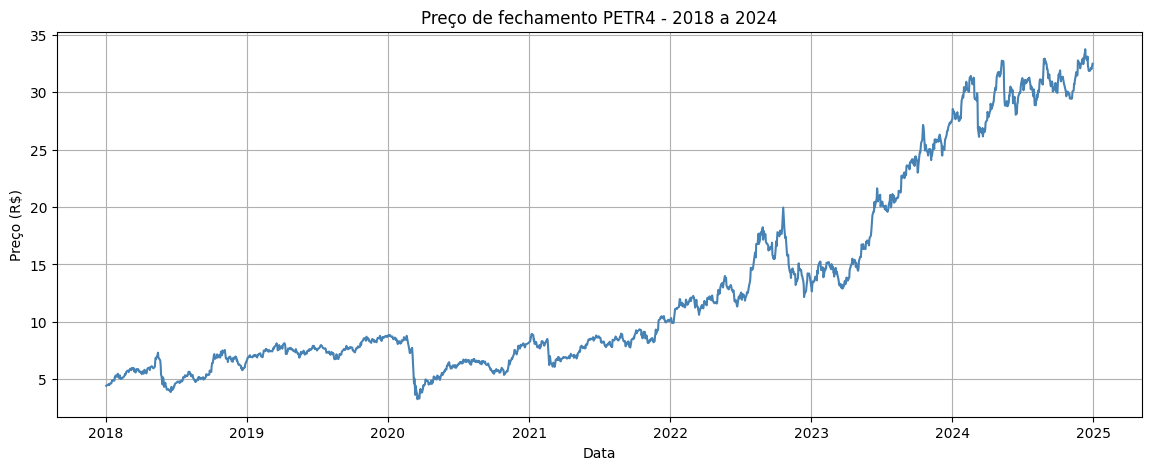

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], color='steelblue')
plt.title('Preço de fechamento PETR4 - 2018 a 2024')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.grid(True)
plt.show()

In [4]:
# Verificando se tem dados faltando
print(df.isnull().sum())

Price   Ticker  
Close   PETR4.SA    0
High    PETR4.SA    0
Low     PETR4.SA    0
Open    PETR4.SA    0
Volume  PETR4.SA    0
dtype: int64


In [5]:
# Pegando só a coluna de fechamento
dados = df['Close'].values.reshape(-1, 1)
print(dados.shape)
print(dados[:5])

(1738, 1)
[[4.40935659]
 [4.44932222]
 [4.45731497]
 [4.48395634]
 [4.53724384]]


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(dados)

print(dados_normalizados[:5])
print(dados_normalizados[-5:])

[[0.03824246]
 [0.03955188]
 [0.03981375]
 [0.04068661]
 [0.0424325 ]]
[[0.93799157]
 [0.93827497]
 [0.94612684]
 [0.94289066]
 [0.95848303]]


In [7]:
def criar_janelas(dados, janela=60):
    X, y = [], []
    for i in range(janela, len(dados)):
        X.append(dados[i-janela:i, 0])
        y.append(dados[i, 0])
    return np.array(X), np.array(y)

X, y = criar_janelas(dados_normalizados)
print(X.shape)
print(y.shape)

(1678, 60)
(1678,)


In [8]:
divisao = int(len(X) * 0.8)

X_treino = X[:divisao]
X_teste = X[divisao:]
y_treino = y[:divisao]
y_teste = y[divisao:]

print(f'Treino: {X_treino.shape}')
print(f'Teste: {X_teste.shape}')

Treino: (1342, 60)
Teste: (336, 60)


In [10]:
# Ajustando o formato para 3 dimensões (exigido pelo LSTM)
# Formato: (exemplos, dias, variáveis)
X_treino = X_treino.reshape((X_treino.shape[0], X_treino.shape[1], 1))
X_teste = X_teste.reshape((X_teste.shape[0], X_teste.shape[1], 1))
print(f'Treino: {X_treino.shape}')
print(f'Teste: {X_teste.shape}')

Treino: (1342, 60, 1)
Teste: (336, 60, 1)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

modelo = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
modelo.compile(optimizer='adam', loss='mean_squared_error')

In [13]:
historico = modelo.fit(
    X_treino, y_treino,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0064 - val_loss: 0.0021
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 9.7911e-04 - val_loss: 0.0016
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 9.2324e-04 - val_loss: 7.4293e-04
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 7.1953e-04 - val_loss: 7.0782e-04
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.7895e-04 - val_loss: 0.0014
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 6.6962e-04 - val_loss: 6.3819e-04
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 6.3978e-04 - val_loss: 0.0013
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 6.4616e-04 - val_loss: 5.9231e-04
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.6325e-04 - val_loss: 9.7543e-04
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 5.5972e-04 - val_loss: 0.0013
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 5.4873e-04 - val_loss: 6.2364e-04

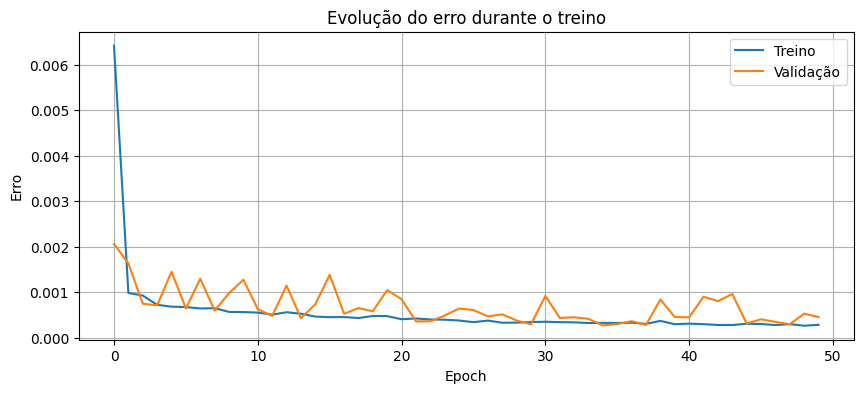

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validação')
plt.title('Evolução do erro durante o treino')
plt.xlabel('Epoch')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


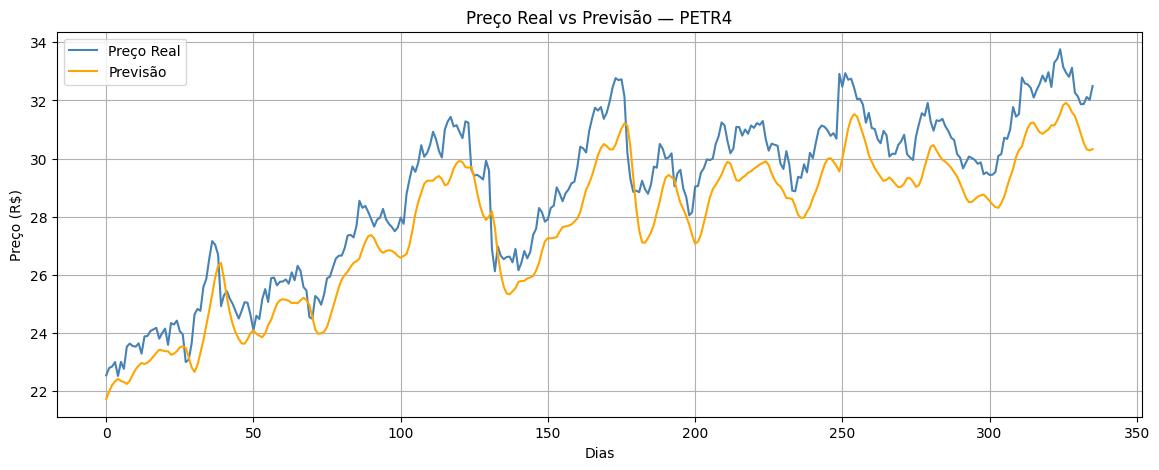

In [15]:
previsoes = modelo.predict(X_teste)

previsoes_reais = scaler.inverse_transform(previsoes)
y_teste_real = scaler.inverse_transform(y_teste.reshape(-1, 1))

plt.figure(figsize=(14, 5))
plt.plot(y_teste_real, label='Preço Real', color='steelblue')
plt.plot(previsoes_reais, label='Previsão', color='orange')
plt.title('Preço Real vs Previsão — PETR4')
plt.xlabel('Dias')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_teste_real, previsoes_reais)
rmse = np.sqrt(mean_squared_error(y_teste_real, previsoes_reais))
mape = np.mean(np.abs((y_teste_real - previsoes_reais) / y_teste_real)) * 100

print(f'MAE:  R$ {mae:.2f}')
print(f'RMSE: R$ {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE:  R$ 1.21
RMSE: R$ 1.32
MAPE: 4.14%


In [17]:
modelo.save('modelo_petr4.keras')
print('Modelo salvo!')

Modelo salvo!


In [18]:
from google.colab import files
files.download('modelo_petr4.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>